In [1]:
import torch
import gc

def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()

clear_gpu()

In [2]:
import os
import time
import random
import pickle
import warnings
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.nn import ChebConv


warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Rulăm pe: {device}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")


 Rulăm pe: cuda
 GPU: NVIDIA GeForce RTX 3080 Laptop GPU


In [3]:
CSV_PATH = "PEMS-BAY.csv"
ADJ_PATH = "Rezultate/adj_mx_bay.pkl"
LOOKBACK = 12
BATCH_SIZE = 64

os.makedirs("Rezultate", exist_ok=True)

# ÎNCĂRCARE GRAF 
with open(ADJ_PATH, 'rb') as f:
    _, _, adj_mx = pickle.load(f)

threshold = 0.1
adj_sparse = adj_mx > threshold

edge_index = torch.tensor(np.array(np.where(adj_sparse)), dtype=torch.long).to(device)
edge_weight = torch.tensor(adj_mx[adj_sparse], dtype=torch.float32).to(device)
print(f" Graf: {edge_index.shape[1]} muchii")

 Graf: 2532 muchii


In [4]:
# Construirea secvențelor de intrare folosind o fereastră temporală
def build_dataset(data, lookback=12):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

print(" Încarcare și procesere date...")
df = pd.read_csv(CSV_PATH).dropna()
data = df.iloc[:, 1:].values.astype(np.float32)

X, y = build_dataset(data, LOOKBACK)

# Construirea secvențelor de intrare folosind o fereastră temporală
n_samples = len(X)
train_end = int(0.7 * n_samples)
val_end   = int(0.85 * n_samples)

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]

# Normalizarea datelor 
n_nodes = X_train.shape[2]
scaler_X = MinMaxScaler()
X_train_s = scaler_X.fit_transform(X_train.reshape(-1, n_nodes)).reshape(X_train.shape)
X_val_s   = scaler_X.transform(X_val.reshape(-1, n_nodes)).reshape(X_val.shape)
X_test_s  = scaler_X.transform(X_test.reshape(-1, n_nodes)).reshape(X_test.shape)

scaler_y = MinMaxScaler()
y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

# Conversia datelor în tensori PyTorch
X_train_t = torch.tensor(X_train_s, dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32)

X_val_t = torch.tensor(X_val_s, dtype=torch.float32).unsqueeze(-1)
y_val_t = torch.tensor(y_val_s, dtype=torch.float32)

X_test_t = torch.tensor(X_test_s, dtype=torch.float32).unsqueeze(-1)
y_test_t = torch.tensor(y_test_s, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f" Split final: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

 Încarcare și procesere date...
 Split final: Train=36472, Val=7816, Test=7816


In [5]:
class STGCN(nn.Module):
    def __init__(self, num_nodes, in_channels=1, hidden_channels=64, K=3, dropout_prob=0.2):
        super(STGCN, self).__init__()
        # Prima convoluție temporală
        self.t_conv1 = nn.Conv2d(in_channels, hidden_channels, kernel_size=(3, 1))
        # Convoluție pe graf
        self.gcn = ChebConv(hidden_channels, hidden_channels, K=K)
        # A doua convoluție temporală
        self.t_conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size=(3, 1))
        self.dropout = nn.Dropout(dropout_prob)
        # Strat complet conectat pentru predicția finală
        self.fc = nn.Linear(hidden_channels * 8, 1)

    def forward(self, x, edge_index, edge_weight):
        # Reordonarea dimensiunilor pentru Conv2D
        x = x.permute(0, 3, 1, 2)
        # Extragerea caracteristicilor temporale
        x = torch.relu(self.t_conv1(x))
        b, c, t, n = x.shape
        # Agregarea informației spațiale folosind graful
        x = x.permute(0, 2, 3, 1).reshape(-1, c)
        x = torch.relu(self.gcn(x, edge_index, edge_weight))
        x = x.reshape(b, t, n, c)
        # Extragerea caracteristicilor temporale finale
        x = x.permute(0, 3, 1, 2)
        x = torch.relu(self.t_conv2(x))
        # Pregătirea pentru stratul de ieșire
        x = x.permute(0, 3, 1, 2)
        x = torch.flatten(x, start_dim=2)
        out = self.fc(self.dropout(x))
        return out.squeeze(-1)

In [6]:
def train_model(model, train_loader, val_loader, lr, edge_index, edge_weight, epochs=50):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    start_train = time.time()
    
    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb, edge_index, edge_weight)
            loss = criterion(out, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            t_loss += loss.item()
            

        model.eval()
        v_loss = 0
        with torch.no_grad():
            for xv, yv in val_loader:
                xv, yv = xv.to(device), yv.to(device)
                v_loss += criterion(model(xv, edge_index, edge_weight), yv).item()   
        train_loss_avg = t_loss / len(train_loader)
        val_loss_avg = v_loss / len(val_loader)
        
        print(f" Epoca {epoch+1:2d}/{epochs} | Train Loss: {train_loss_avg:.6f} | Val Loss: {val_loss_avg:.6f}")
                
    print(f" Antrenare finală completată în {(time.time() - start_train)/60:.2f} minute.")
    return model

In [7]:
def fitness_stgcn(params, edge_index, edge_weight):
    h_channels = int(round(params[0]))
    lr_val = 10**params[1]
    dropout_val = np.clip(10**params[2], 0.0, 0.4)
    batch_options = [16, 32, 64]
    idx = int(np.clip(round(params[3]), 0, len(batch_options) - 1))
    batch_val = batch_options[idx]
    
    try:
        train_loader_tmp = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_val, shuffle=True)
        val_loader_tmp   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_val, shuffle=False)

        model_tmp = STGCN(
            num_nodes=325, 
            in_channels=1, 
            hidden_channels=h_channels, 
            K=3,
            dropout_prob=dropout_val
        ).to(device)
        
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model_tmp.parameters(), lr=lr_val)
        
        for epoch in range(10):
            model_tmp.train()
            for xb, yb in train_loader_tmp:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                pred = model_tmp(xb, edge_index, edge_weight)
                loss = criterion(pred, yb)
                if torch.isnan(loss):
                    return 1e6
                    
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model_tmp.parameters(), 1.0)
                optimizer.step()
                
        # EVALUARE PE SETUL DE VALIDARE 
        model_tmp.eval()
        val_loss_total = 0
        with torch.no_grad():
            for xv, yv in val_loader_tmp:
                xv, yv = xv.to(device), yv.to(device)
                v_pred = model_tmp(xv, edge_index, edge_weight)
                val_loss_total += criterion(v_pred, yv).item()

        return val_loss_total / len(val_loader_tmp)

    except Exception as e:
        return 1e6
        
    finally:
        if 'model_tmp' in locals():
            del model_tmp
        torch.cuda.empty_cache()

In [8]:
class PSO_Hyper:
    def __init__(self, func, population=10, max_iter=5):
        self.func = func
        self.dim = 4 
        self.lb = np.array([24, -4.0, -3.0, 0.0])   \
        self.ub = np.array([64, -2.0, -0.4, 2.99])  
        self.population = population
        self.max_iter = max_iter
        self.v_max = (self.ub - self.lb) * 0.2
        self.positions = np.random.uniform(self.lb, self.ub, (population, self.dim))
        self.velocities = np.zeros((population, self.dim))
        self.cache = {}
        self.pbest = self.positions.copy()
        self.pbest_val = np.array([self.evaluate(p) for p in self.positions])
        best_idx = np.argmin(self.pbest_val)
        self.gbest = self.pbest[best_idx].copy()
        self.gbest_val = self.pbest_val[best_idx]

    def evaluate(self, p):
        key = tuple(np.round(p, 4))

        if key in self.cache:
            return self.cache[key]

        try:
            val = self.func(p)
            if np.isnan(val) or val > 1e6:
                val = 1e6
        except:
            val = 1e6

        self.cache[key] = val
        return val

    def optimize(self):
        c1, c2 = 1.5, 1.5

        for it in range(self.max_iter):
            w = 0.9 - (0.5 * (it / self.max_iter))

            for i in range(self.population):
                r1, r2 = np.random.rand(self.dim), np.random.rand(self.dim)

                self.velocities[i] = (
                    w * self.velocities[i]
                    + c1 * r1 * (self.pbest[i] - self.positions[i])
                    + c2 * r2 * (self.gbest - self.positions[i])
                )

                self.velocities[i] = np.clip(self.velocities[i], -self.v_max, self.v_max)

                # Actualizare poziție particulă
                self.positions[i] += self.velocities[i]
                self.positions[i] = np.clip(self.positions[i], self.lb, self.ub)

                # Evaluare cost nouă poziție
                fit = self.evaluate(self.positions[i])

                # Update Personal Best (pbest)
                if fit < self.pbest_val[i]:
                    self.pbest[i] = self.positions[i].copy()
                    self.pbest_val[i] = fit

                # Update Global Best (gbest)
                if fit < self.gbest_val:
                    self.gbest = self.positions[i].copy()
                    self.gbest_val = fit

            best_channels = int(round(self.gbest[0]))
            best_lr = 10 ** self.gbest[1]
            best_dropout = np.clip(10 ** self.gbest[2], 0.0, 0.4)
            batch_options = [16, 32, 64]
            best_batch_idx = int(np.clip(round(self.gbest[3]), 0, len(batch_options) - 1))
            best_batch = batch_options[best_batch_idx]

            print(f" PSO Iter {it+1:2d}/{self.max_iter} | Best Cost: {self.gbest_val:.6f} | "
                  f"Channels: {best_channels} | LR: {best_lr:.6f} | Dropout: {best_dropout:.4f} | Batch: {best_batch}")

        return self.gbest, self.gbest_val

In [9]:
#  RULARE OPTIMIZARE PSO
print("\n Pornesc Optimizarea PSO pentru STGCN...")
start_pso = time.time()
torch.cuda.empty_cache()

pso = PSO_Hyper(func=lambda p: fitness_stgcn(p, edge_index, edge_weight), population=10, max_iter=5)
best_params, best_cost = pso.optimize()

print(f" Optimizarea PSO completă în {(time.time() - start_pso)/60:.2f} minute.")

h_channels_opt = int(round(best_params[0]))
lr_opt = 10 ** best_params[1]
dropout_opt = np.clip(10 ** best_params[2], 0.0, 0.4)
batch_options = [16, 32, 64]
batch_opt_idx = int(np.clip(round(best_params[3]), 0, len(batch_options) - 1))
batch_opt = batch_options[batch_opt_idx]

print("\n PARAMETRI OPTIMI REZULTAȚI DIN PSO:")
print(f"   Canale (Hidden): {h_channels_opt}")
print(f"   Learning Rate:   {lr_opt:.6f}")
print(f"   Dropout:         {dropout_opt:.4f}")
print(f"   Batch Size:      {batch_opt}")

#  ANTRENARE MODEL FINAL
print(f"\n Începe antrenarea modelului final cu parametrii optimi ...")
start_final_train = time.time()

train_loader_final = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_opt, shuffle=True)
val_loader_final   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_opt, shuffle=False)

model_final = STGCN(
    num_nodes=325,
    in_channels=1, 
    hidden_channels=h_channels_opt, 
    K=3,
    dropout_prob=dropout_opt
).to(device)

model_final = train_model(
    model=model_final,
    train_loader=train_loader_final,
    val_loader=val_loader_final,
    lr=lr_opt,
    edge_index=edge_index,
    edge_weight=edge_weight,
    epochs=50
)

print(f" Antrenare finală completată în {(time.time() - start_final_train)/60:.2f} minute.")


 Pornesc Optimizarea PSO pentru STGCN...
 PSO Iter  1/5 | Best Cost: 0.000737 | Channels: 36 | LR: 0.001121 | Dropout: 0.0133 | Batch: 32
 PSO Iter  2/5 | Best Cost: 0.000722 | Channels: 37 | LR: 0.001135 | Dropout: 0.0288 | Batch: 32
 PSO Iter  3/5 | Best Cost: 0.000722 | Channels: 37 | LR: 0.001135 | Dropout: 0.0288 | Batch: 32
 PSO Iter  4/5 | Best Cost: 0.000722 | Channels: 37 | LR: 0.001135 | Dropout: 0.0288 | Batch: 32
 PSO Iter  5/5 | Best Cost: 0.000722 | Channels: 37 | LR: 0.001135 | Dropout: 0.0288 | Batch: 32
 Optimizarea PSO completă în 155.39 minute.

 PARAMETRI OPTIMI REZULTAȚI DIN PSO:
   Canale (Hidden): 37
   Learning Rate:   0.001135
   Dropout:         0.0288
   Batch Size:      32

 Începe antrenarea modelului final cu parametrii optimi ...
 Epoca  1/50 | Train Loss: 0.003765 | Val Loss: 0.000852
 Epoca  2/50 | Train Loss: 0.000881 | Val Loss: 0.000808
 Epoca  3/50 | Train Loss: 0.000829 | Val Loss: 0.000805
 Epoca  4/50 | Train Loss: 0.000795 | Val Loss: 0.000814


In [10]:
# EVALUARE FINALĂ 
print("\n Evaluare pe setul de test...")
model_final.eval()
all_preds = []

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader_final = DataLoader(test_dataset, batch_size=batch_opt, shuffle=False)


with torch.no_grad():
    for xt, _ in test_loader_final:
        xt = xt.to(device)
        pred = model_final(xt, edge_index, edge_weight)
        all_preds.append(pred.cpu())

pred_test = torch.cat(all_preds, dim=0).numpy()
y_pred_inv = scaler_y.inverse_transform(pred_test)
y_real_inv = scaler_y.inverse_transform(y_test_s)

# Calcul metrici 
mse = mean_squared_error(y_real_inv, y_pred_inv)
mae = mean_absolute_error(y_real_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_real_inv, y_pred_inv)
var_ratio = np.var(y_pred_inv) / np.var(y_real_inv)

print("\n REZULTATE FINALE (STGCN-PSO):")
print(f"  MSE  : {mse:.4f}")
print(f"  MAE  : {mae:.4f} mph")
print(f"  RMSE : {rmse:.4f}")
print(f"  R2   : {r2:.4f}")
print(f"  Var  : {var_ratio:.4f}")


results_path = "Rezultate/log_experimente.csv"

results = {
    "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
    "model": "STGCN_PSO",
    "version": "v5",
    "lookback": LOOKBACK,
    "gcn_channels": h_channels_opt,
    "learning_rate": f"{lr_opt:.6f}",
    "dropout": f"{dropout_opt:.4f}",     
    "batch_size": batch_opt,             
    "epochs": 50,
    "MSE": f"{mse:.6f}",
    "MAE": f"{mae:.4f}",
    "RMSE": f"{rmse:.4f}",
    "R2": f"{r2:.4f}",
    "Var_Ratio": f"{var_ratio:.4f}"
}

pd.DataFrame([results]).to_csv(
    results_path,
    mode='a',
    header=not os.path.exists(results_path),
    index=False
)

np.save("Rezultate/preds_STGCN_PSO_V5.npy", y_pred_inv)
print(f"\n Rezultatele și predicțiile au fost salvate cu succes în '{results_path}'!")


 Evaluare pe setul de test...

 REZULTATE FINALE (STGCN-PSO):
  MSE  : 3.1506
  MAE  : 0.9324 mph
  RMSE : 1.7750
  R2   : 0.9373
  Var  : 0.9708

 Rezultatele și predicțiile au fost salvate cu succes în 'Rezultate/log_experimente.csv'!


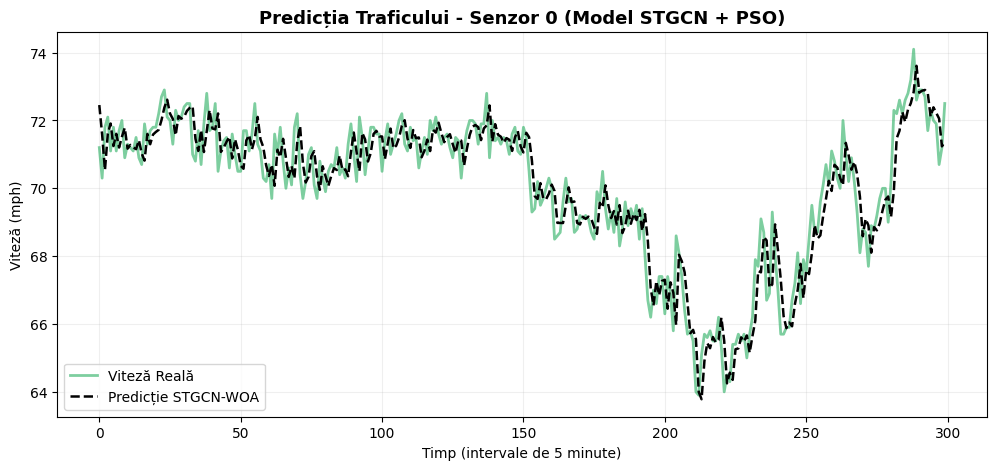


[INFO] Generez schema arhitecturii...


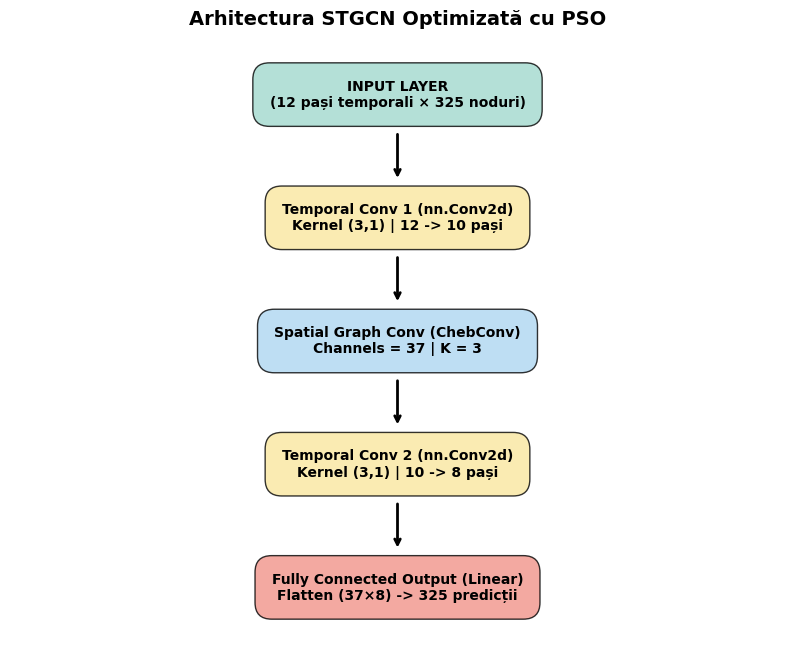

[INFO] Generez analiza comparativă Senzor Bun vs Senzor Slab...


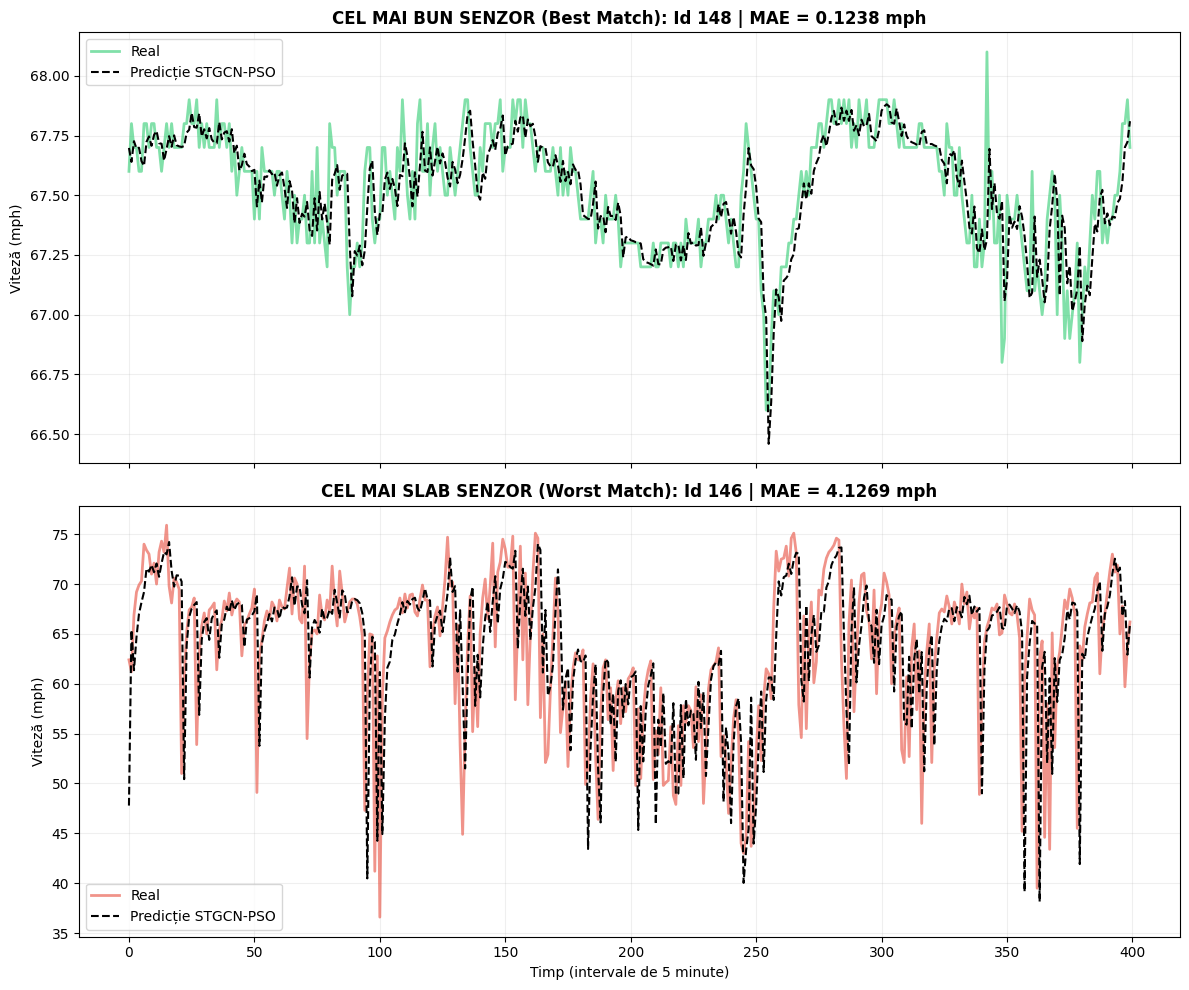

 Toate vizualizările au fost generate și salvate cu succes în folderul 'Rezultate'!


In [11]:
#Vizualizare grafice predictii

os.makedirs("Rezultate", exist_ok=True)

# Comparația dintre valorile reale și predicții

plt.figure(figsize=(12, 5))

plt.plot(
    y_real_inv[:300, 0],
    label="Viteză Reală",
    color='#27ae60',
    alpha=0.6,
    linewidth=2
)

plt.plot(
    y_pred_inv[:300, 0],
    '--',
    label="Predicție STGCN-WOA",
    color='black',
    linewidth=1.8
)

plt.title(
    "Predicția Traficului - Senzor 0 (Model STGCN + PSO)",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel("Viteză (mph)")
plt.xlabel("Timp (intervale de 5 minute)")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.2)

plt.savefig("Rezultate/Predictie_Senzor_0_STGCN_PSO.png", dpi=300, bbox_inches='tight')
plt.show()


#  ARHITECTURĂ STGCN-PSO

def plot_stgcn_architecture(num_nodes, gcn_f, lookback_val):
    fig, ax = plt.subplots(figsize=(10, 8))

    layers = [
        f"INPUT LAYER\n({lookback_val} pași temporali × {num_nodes} noduri)",
        f"Temporal Conv 1 (nn.Conv2d)\nKernel (3,1) | {lookback_val} -> 10 pași",
        f"Spatial Graph Conv (ChebConv)\nChannels = {gcn_f} | K = 3",
        f"Temporal Conv 2 (nn.Conv2d)\nKernel (3,1) | 10 -> 8 pași",
        f"Fully Connected Output (Linear)\nFlatten ({gcn_f}×8) -> {num_nodes} predicții"
    ]

    y_pos = range(len(layers), 0, -1)

    for i, txt in enumerate(layers):
        if "INPUT" in txt:
            color = '#a2d9ce'
        elif "Temporal" in txt:
            color = '#f9e79f'
        elif "Spatial" in txt:
            color = '#aed6f1'
        elif "Output" in txt:
            color = '#f1948a'
        else:
            color = 'lightgray'

        ax.text(
            0.5, y_pos[i], txt,
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=1.2', facecolor=color, alpha=0.8)
        )

        if i < len(layers) - 1:
            ax.annotate(
                '',
                xy=(0.5, y_pos[i+1]+0.3),
                xytext=(0.5, y_pos[i]-0.3),
                arrowprops=dict(arrowstyle='->', lw=2)
            )

    plt.title("Arhitectura STGCN Optimizată cu PSO", fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, len(layers) + 0.5)
    ax.axis('off')

    plt.savefig("Rezultate/Arhitectura_STGCN_PSO.png", dpi=300, bbox_inches='tight')
    plt.show()
plot_stgcn_architecture(325, h_channels_opt, LOOKBACK)



# Identificarea senzorilor cu cea mai bună și cea mai slabă performanță
mae_per_sensor = np.mean(np.abs(y_real_inv - y_pred_inv), axis=0)
best_s = np.argmin(mae_per_sensor)
worst_s = np.argmax(mae_per_sensor)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# BEST SENSOR
ax1.plot(
    y_real_inv[:400, best_s],
    label="Real",
    color='#2ecc71',
    alpha=0.6,
    linewidth=2
)

ax1.plot(
    y_pred_inv[:400, best_s],
    '--',
    label="Predicție STGCN-PSO",
    color='black',
    linewidth=1.5
)

ax1.set_title(
    f"CEL MAI BUN SENZOR (Best Match): Id {best_s} | MAE = {mae_per_sensor[best_s]:.4f} mph",
    fontsize=12,
    fontweight='bold'
)
ax1.set_ylabel("Viteză (mph)")
ax1.legend()
ax1.grid(True, alpha=0.2)

# WORST SENSOR
ax2.plot(
    y_real_inv[:400, worst_s],
    label="Real",
    color='#e74c3c',
    alpha=0.6,
    linewidth=2
)

ax2.plot(
    y_pred_inv[:400, worst_s],
    '--',
    label="Predicție STGCN-PSO",
    color='black',
    linewidth=1.5
)

ax2.set_title(
    f"CEL MAI SLAB SENZOR (Worst Match): Id {worst_s} | MAE = {mae_per_sensor[worst_s]:.4f} mph",
    fontsize=12,
    fontweight='bold'
)
ax2.set_ylabel("Viteză (mph)")
ax2.set_xlabel("Timp (intervale de 5 minute)")
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("Rezultate/Analiza_Senzori_STGCN_PSO.png", dpi=300, bbox_inches='tight')
plt.show()